# Project 1: Multi-Model Sentiment Ensemble
## Notebook 4: VADER + RoBERTa Two-Model Ensemble

This notebook builds a production-ready two-model ensemble using VADER and RoBERTa 
on the full sentiment test set (12,284 tweets). Llama 3 is excluded here because:
1. It was evaluated on a 1,000-tweet sample only
2. It cannot run on HuggingFace Spaces (requires local Ollama)

This ensemble forms the basis of the Gradio demo deployed to HuggingFace Spaces.

In [9]:
# Imports and reload
from datasets import load_dataset
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

# Load dataset
sentiment = load_dataset('tweet_eval', 'sentiment')
sentiment_test = pd.DataFrame(sentiment['test'])
true_labels = sentiment_test['label'].tolist()
all_tweets = sentiment_test['text'].tolist()

print(f"Test set size: {len(sentiment_test)}")
print(f"CUDA available: {torch.cuda.is_available()}")

Test set size: 12284
CUDA available: True


In [10]:
# VADER on full test set
sia = SentimentIntensityAnalyzer()

vader_predictions = []
vader_probs = []

print("Running VADER on full test set...")
for tweet in all_tweets:
    scores = sia.polarity_scores(tweet)
    compound = scores['compound']
    
    if compound >= 0.05:
        vader_predictions.append(2)
        vader_probs.append([0.1, 0.1, 0.8])
    elif compound <= -0.05:
        vader_predictions.append(0)
        vader_probs.append([0.8, 0.1, 0.1])
    else:
        vader_predictions.append(1)
        vader_probs.append([0.1, 0.8, 0.1])

print(f"VADER done: {len(vader_predictions)} predictions")

Running VADER on full test set...
VADER done: 12284 predictions


In [11]:
# RoBERTa on full test set

model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model = model.to('cuda')
model.eval()

def predict_roberta(texts, model, tokenizer, device='cuda'):
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)
    
    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.float16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    
    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)
    return preds.cpu().numpy(), probs.cpu().numpy()

batches = [all_tweets[i:i+32] for i in range(0, len(all_tweets), 32)]
roberta_predictions = []
roberta_probs = []

print("Running RoBERTa on full test set...")
for i, batch in enumerate(batches):
    preds, probs = predict_roberta(batch, model, tokenizer)
    roberta_predictions.extend(preds)
    roberta_probs.extend(probs)
    if i % 50 == 0:
        print(f"  Batch {i}/{len(batches)}...")

print(f"RoBERTa done: {len(roberta_predictions)} predictions")

/home/valkeo/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification 

Running RoBERTa on full test set...
  Batch 0/384...
  Batch 50/384...
  Batch 100/384...
  Batch 150/384...
  Batch 200/384...
  Batch 250/384...
  Batch 300/384...
  Batch 350/384...
RoBERTa done: 12284 predictions


In [12]:
# Strategy 1 — Majority Vote (tie goes to RoBERTa since it's stronger)
def majority_vote_2model(vader_preds, roberta_preds):
    ensemble_preds = []
    for v, r in zip(vader_preds, roberta_preds):
        if v == r:
            ensemble_preds.append(v)
        else:
            # Tie — defer to RoBERTa
            ensemble_preds.append(r)
    return ensemble_preds

In [13]:
# Strategy 2 — Confidence Weighted
def confidence_weighted_2model(vader_probs, roberta_probs):
    ensemble_preds = []
    for v_prob, r_prob in zip(vader_probs, roberta_probs):
        class_scores = np.array([0.0, 0.0, 0.0])
        class_scores += np.array(v_prob) * vader_weight
        class_scores += np.array(r_prob) * roberta_weight
        ensemble_preds.append(int(np.argmax(class_scores)))
    return ensemble_preds

In [14]:
# Run all strategies
majority_preds = majority_vote_2model(vader_predictions, roberta_predictions)
weighted_preds = weighted_vote_2model(vader_predictions, roberta_predictions)
confidence_preds = confidence_weighted_2model(vader_probs, roberta_probs)

In [15]:
def compute_metrics(true, predicted, name):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted, average='macro')
    f1_classes = f1_score(true, predicted, average=None)
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1-macro: {f1:.3f}")
    print(f"  F1 per class: neg={f1_classes[0]:.3f} neu={f1_classes[1]:.3f} pos={f1_classes[2]:.3f}")
    return acc, f1, f1_classes

print("=" * 60)
print("TWO-MODEL ENSEMBLE RESULTS — Full test set (12,284 tweets)")
print("=" * 60)

compute_metrics(true_labels, vader_predictions, "VADER (baseline)")
compute_metrics(true_labels, roberta_predictions, "RoBERTa (baseline)")

print("\n--- Two-Model Ensemble Strategies ---")
maj_acc, maj_f1, maj_f1c = compute_metrics(true_labels, majority_preds, "Majority Vote (tie→RoBERTa)")
cf_acc, cf_f1, cf_f1c = compute_metrics(true_labels, confidence_preds, "Confidence Weighted")
print("=" * 60)

TWO-MODEL ENSEMBLE RESULTS — Full test set (12,284 tweets)

VADER (baseline):
  Accuracy: 0.530
  F1-macro: 0.529
  F1 per class: neg=0.582 neu=0.530 pos=0.474

RoBERTa (baseline):
  Accuracy: 0.722
  F1-macro: 0.724
  F1 per class: neg=0.743 neu=0.704 pos=0.725

--- Two-Model Ensemble Strategies ---

Majority Vote (tie→RoBERTa):
  Accuracy: 0.722
  F1-macro: 0.724
  F1 per class: neg=0.743 neu=0.704 pos=0.725

Confidence Weighted:
  Accuracy: 0.687
  F1-macro: 0.687
  F1 per class: neg=0.730 neu=0.664 pos=0.666


Doing some extra work to understand how to use VADER in the final pipeline, given its weaknesses in contrast to RoBERTa.

In [16]:
# How many truly negative tweets does VADER miss?
vader_arr = np.array(vader_predictions)
true_arr = np.array(true_labels)

# Truly negative tweets
truly_negative = true_arr == 0
total_negative = truly_negative.sum()

# Truly negative tweets that VADER correctly flags as negative
vader_catches = ((vader_arr == 0) & (true_arr == 0)).sum()

# Truly negative tweets VADER mislabels
vader_misses = total_negative - vader_catches

print(f"Total truly negative tweets: {total_negative}")
print(f"VADER correctly flags as negative: {vader_catches} ({vader_catches/total_negative*100:.1f}%)")
print(f"VADER misses (labels positive/neutral): {vader_misses} ({vader_misses/total_negative*100:.1f}%)")
print(f"\nBreakdown of VADER's errors on negative tweets:")
print(f"  Called positive: {((vader_arr == 2) & (true_arr == 0)).sum()}")
print(f"  Called neutral:  {((vader_arr == 1) & (true_arr == 0)).sum()}")

Total truly negative tweets: 3972
VADER correctly flags as negative: 2222 (55.9%)
VADER misses (labels positive/neutral): 1750 (44.1%)

Breakdown of VADER's errors on negative tweets:
  Called positive: 1025
  Called neutral:  725


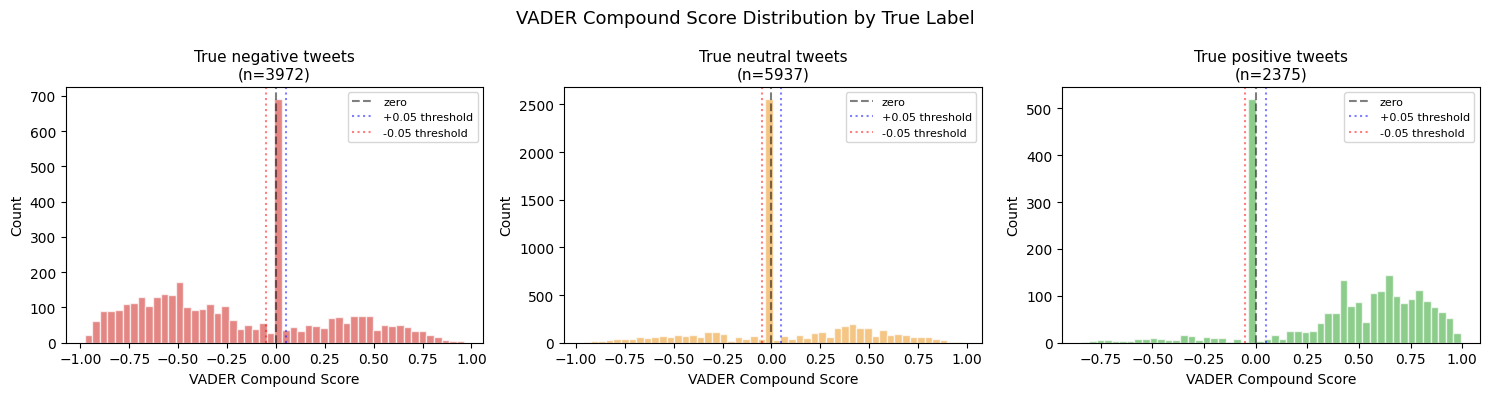

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get compound scores for all test tweets
compound_scores = []
for tweet in all_tweets:
    scores = sia.polarity_scores(tweet)
    compound_scores.append(scores['compound'])

compound_arr = np.array(compound_scores)
true_arr = np.array(true_labels)

# Distribution of compound scores by true label
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
colors = {0: '#d9534f', 1: '#f0ad4e', 2: '#5cb85c'}

for label_id in [0, 1, 2]:
    ax = axes[label_id]
    scores = compound_arr[true_arr == label_id]
    ax.hist(scores, bins=50, color=colors[label_id], alpha=0.7, edgecolor='white')
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='zero')
    ax.axvline(x=0.05, color='blue', linestyle=':', alpha=0.5, label='+0.05 threshold')
    ax.axvline(x=-0.05, color='red', linestyle=':', alpha=0.5, label='-0.05 threshold')
    ax.set_title(f'True {label_names[label_id]} tweets\n(n={len(scores)})', fontsize=11)
    ax.set_xlabel('VADER Compound Score', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('VADER Compound Score Distribution by True Label', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/vader_compound_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

VADER struggles as a successful classifier. The negative graph would ideally skew left, like the positive graph skews right. The fact that it does not skew is indicative of the 44% miss rate with negative tweets.

What we can do, is use VADER's compound score (which is between -1.0 and +1.0), and use it as an additional signal with RoBERTa's confidence score.
For example:
> RoBERTa: negative (confidence 0.62)

> VADER compound: +0.3

> Gap between RoBERTa and VADER = large, so elevate to HIGH priority

VADER HIGH CONFIDENCE PREDICTIONS

Compound >= 0.8 (high confidence positive):
  Total tweets:          508 (4.1%)
  Actually positive:     343 (67.5%)
  Actually neutral:      125 (24.6%)
  Actually negative:     40 (7.9%)

Compound <= -0.8 (high confidence negative):
  Total tweets:          399 (3.2%)
  Actually negative:     314 (78.7%)
  Actually neutral:      83 (20.8%)
  Actually positive:     2 (0.5%)


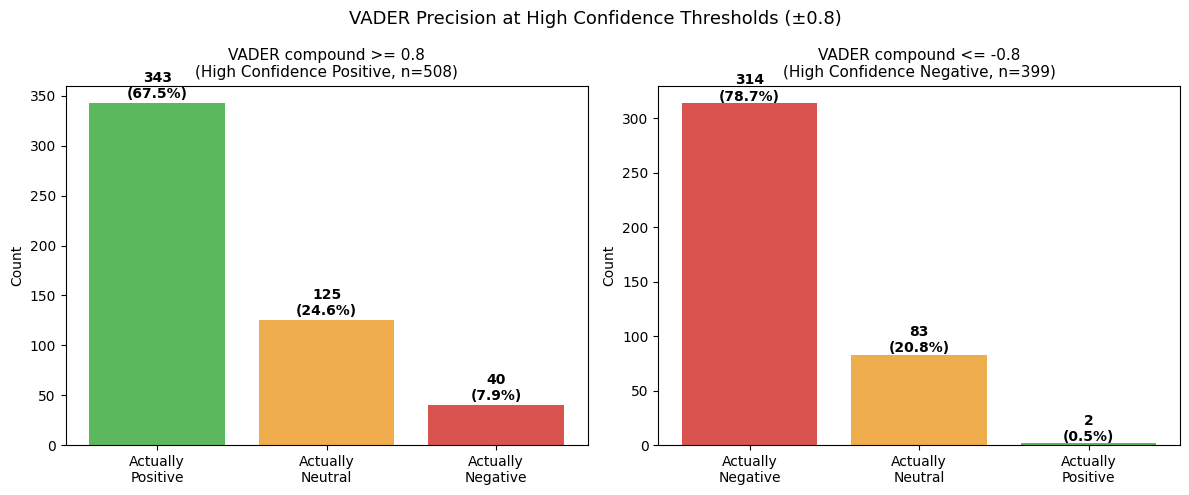

In [23]:
# Define high confidence thresholds
high_positive_threshold = 0.8
high_negative_threshold = -0.8

# Count tweets at each extreme
high_positive = compound_arr >= high_positive_threshold
high_negative = compound_arr <= high_negative_threshold

print("=" * 60)
print("VADER HIGH CONFIDENCE PREDICTIONS")
print("=" * 60)
print(f"\nCompound >= {high_positive_threshold} (high confidence positive):")
print(f"  Total tweets:          {high_positive.sum()} ({high_positive.sum()/len(compound_arr)*100:.1f}%)")
print(f"  Actually positive:     {((high_positive) & (true_arr == 2)).sum()} ({((high_positive) & (true_arr == 2)).sum()/high_positive.sum()*100:.1f}%)")
print(f"  Actually neutral:      {((high_positive) & (true_arr == 1)).sum()} ({((high_positive) & (true_arr == 1)).sum()/high_positive.sum()*100:.1f}%)")
print(f"  Actually negative:     {((high_positive) & (true_arr == 0)).sum()} ({((high_positive) & (true_arr == 0)).sum()/high_positive.sum()*100:.1f}%)")

print(f"\nCompound <= {high_negative_threshold} (high confidence negative):")
print(f"  Total tweets:          {high_negative.sum()} ({high_negative.sum()/len(compound_arr)*100:.1f}%)")
print(f"  Actually negative:     {((high_negative) & (true_arr == 0)).sum()} ({((high_negative) & (true_arr == 0)).sum()/high_negative.sum()*100:.1f}%)")
print(f"  Actually neutral:      {((high_negative) & (true_arr == 1)).sum()} ({((high_negative) & (true_arr == 1)).sum()/high_negative.sum()*100:.1f}%)")
print(f"  Actually positive:     {((high_negative) & (true_arr == 2)).sum()} ({((high_negative) & (true_arr == 2)).sum()/high_negative.sum()*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# High confidence positive
pos_labels = ['Actually\nPositive', 'Actually\nNeutral', 'Actually\nNegative']
pos_counts = [
    ((high_positive) & (true_arr == 2)).sum(),
    ((high_positive) & (true_arr == 1)).sum(),
    ((high_positive) & (true_arr == 0)).sum()
]
axes[0].bar(pos_labels, pos_counts, color=['#5cb85c', '#f0ad4e', '#d9534f'])
axes[0].set_title(f'VADER compound >= {high_positive_threshold}\n(High Confidence Positive, n={high_positive.sum()})', fontsize=11)
axes[0].set_ylabel('Count', fontsize=10)
for i, v in enumerate(pos_counts):
    axes[0].text(i, v + 5, f'{v}\n({v/high_positive.sum()*100:.1f}%)', 
                ha='center', fontsize=10, fontweight='bold')

# High confidence negative
neg_labels = ['Actually\nNegative', 'Actually\nNeutral', 'Actually\nPositive']
neg_counts = [
    ((high_negative) & (true_arr == 0)).sum(),
    ((high_negative) & (true_arr == 1)).sum(),
    ((high_negative) & (true_arr == 2)).sum()
]
axes[1].bar(neg_labels, neg_counts, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[1].set_title(f'VADER compound <= {high_negative_threshold}\n(High Confidence Negative, n={high_negative.sum()})', fontsize=11)
axes[1].set_ylabel('Count', fontsize=10)
for i, v in enumerate(neg_counts):
    axes[1].text(i, v + 2, f'{v}\n({v/high_negative.sum()*100:.1f}%)', 
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('VADER Precision at High Confidence Thresholds (±0.8)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/vader_high_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

I considered using VADER as a step prior to RoBERTa, if the compound score was a negative extreme like -0.8, immediately flag as high priority for human review, or possibly auto-action. And it seems like this might be possible given the % of actually negative posts at -0.8.

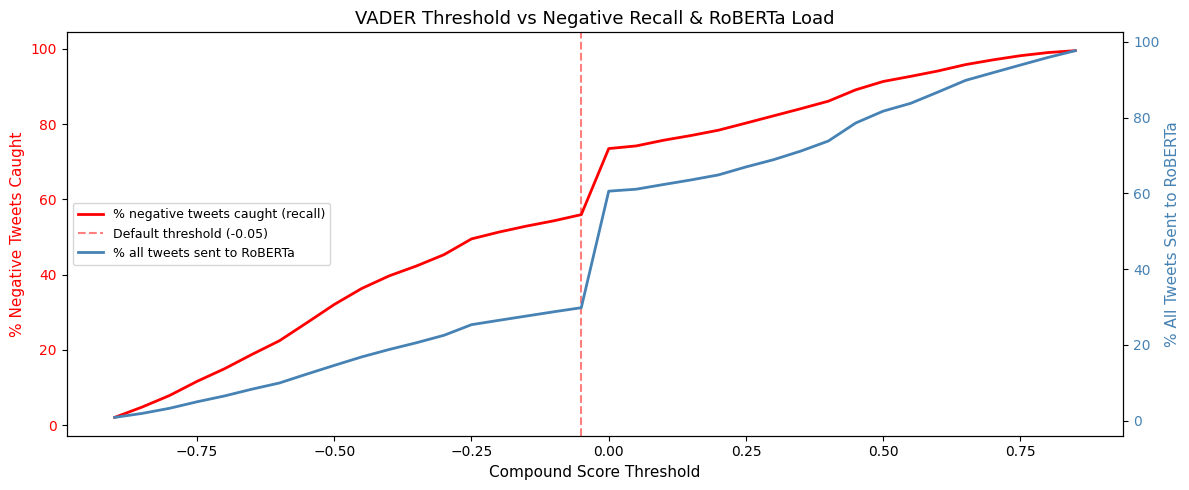

Threshold    % Neg Caught       % Tweets to RoBERTa
-0.5         32.1               14.6%
-0.3         45.3               22.5%
-0.05        55.9               29.8%
0.0          73.5               60.6%
0.3          82.2               68.9%
0.5          91.3               81.7%
0.8          99.0               95.9%


In [20]:
# % of truly negative tweets caught at each threshold
thresholds = np.arange(-0.9, 0.9, 0.05)
recall_at_threshold = []
pct_sent_to_roberta = []

truly_negative = true_arr == 0
total_negative = truly_negative.sum()
total_tweets = len(true_arr)

for threshold in thresholds:
    # Tweets sent to RoBERTa = those with compound <= threshold
    sent_to_roberta = compound_arr <= threshold
    
    # Of truly negative tweets, how many get sent to RoBERTa?
    caught = (sent_to_roberta & truly_negative).sum()
    recall = caught / total_negative
    pct_sent = sent_to_roberta.sum() / total_tweets * 100
    
    recall_at_threshold.append(recall)
    pct_sent_to_roberta.append(pct_sent)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(thresholds, [r * 100 for r in recall_at_threshold], 
         color='red', linewidth=2, label='% negative tweets caught (recall)')
ax1.set_xlabel('Compound Score Threshold', fontsize=11)
ax1.set_ylabel('% Negative Tweets Caught', fontsize=11, color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.axvline(x=-0.05, color='red', linestyle='--', alpha=0.5, label='Default threshold (-0.05)')

ax2 = ax1.twinx()
ax2.plot(thresholds, pct_sent_to_roberta, 
         color='steelblue', linewidth=2, label='% all tweets sent to RoBERTa')
ax2.set_ylabel('% All Tweets Sent to RoBERTa', fontsize=11, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('VADER Threshold vs Negative Recall & RoBERTa Load', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/vader_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

# Table of key thresholds
print("=" * 60)
print(f"{'Threshold':<12} {'% Neg Caught':<18} {'% Tweets to RoBERTa'}")
print("=" * 60)
key_thresholds = [-0.5, -0.3, -0.05, 0.0, 0.3, 0.5, 0.8]
for t in key_thresholds:
    sent = (compound_arr <= t)
    caught = (sent & truly_negative).sum() / total_negative * 100
    pct = sent.sum() / total_tweets * 100
    print(f"{t:<12} {caught:<18.1f} {pct:.1f}%")
print("=" * 60)

The best performing model strategy was majority vote. The F1-macro scores collected here will be used in final pipeline. VADER misclassified 44% of negative tweets from this dataset. In cases where VADER and RoBERTa disagree, I will elevate the priority of the tweet to high. Instead of using VADER's label, I will use its compound score as a supplementary signal. The above graph proves that VADER alone is unsuitable as a pre-filter, and instead must be used as a disagreement signal.

In [25]:
# Get RoBERTa confidence scores
roberta_arr = np.array(roberta_predictions)
roberta_conf = np.array([max(p) for p in roberta_probs])

# High confidence negative — both models strongly agree
roberta_negative = roberta_arr == 0
vader_strongly_negative = compound_arr <= -0.8

high_conf_negative = roberta_negative & vader_strongly_negative
borderline_negative = roberta_negative & ~vader_strongly_negative

print("=" * 60)
print("NEGATIVE TWEET CONFIDENCE BUCKETS")
print("=" * 60)
print(f"\nTotal tweets RoBERTa calls negative: {roberta_negative.sum()}")
print(f"\nHigh confidence (RoBERTa neg + VADER <= -0.8):")
print(f"  Count: {high_conf_negative.sum()} ({high_conf_negative.sum()/roberta_negative.sum()*100:.1f}% of negatives)")
print(f"  Actually negative: {((high_conf_negative) & (true_arr == 0)).sum()} ({((high_conf_negative) & (true_arr == 0)).sum()/high_conf_negative.sum()*100:.1f}%)")
print(f"  Actually neutral:  {((high_conf_negative) & (true_arr == 1)).sum()} ({((high_conf_negative) & (true_arr == 1)).sum()/high_conf_negative.sum()*100:.1f}%)")
print(f"  Actually positive: {((high_conf_negative) & (true_arr == 2)).sum()} ({((high_conf_negative) & (true_arr == 2)).sum()/high_conf_negative.sum()*100:.1f}%)")

print(f"\nBorderline (RoBERTa neg + VADER > -0.8):")
print(f"  Count: {borderline_negative.sum()} ({borderline_negative.sum()/roberta_negative.sum()*100:.1f}% of negatives)")
print(f"  Actually negative: {((borderline_negative) & (true_arr == 0)).sum()} ({((borderline_negative) & (true_arr == 0)).sum()/borderline_negative.sum()*100:.1f}%)")
print(f"  Actually neutral:  {((borderline_negative) & (true_arr == 1)).sum()} ({((borderline_negative) & (true_arr == 1)).sum()/borderline_negative.sum()*100:.1f}%)")
print(f"  Actually positive: {((borderline_negative) & (true_arr == 2)).sum()} ({((borderline_negative) & (true_arr == 2)).sum()/borderline_negative.sum()*100:.1f}%)")

NEGATIVE TWEET CONFIDENCE BUCKETS

Total tweets RoBERTa calls negative: 4647

High confidence (RoBERTa neg + VADER <= -0.8):
  Count: 363 (7.8% of negatives)
  Actually negative: 301 (82.9%)
  Actually neutral:  61 (16.8%)
  Actually positive: 1 (0.3%)

Borderline (RoBERTa neg + VADER > -0.8):
  Count: 4284 (92.2% of negatives)
  Actually negative: 2903 (67.8%)
  Actually neutral:  1311 (30.6%)
  Actually positive: 70 (1.6%)


### Negative Tweet Confidence Buckets

Only 363 tweets (7.8% of all negatives) fall into the "high confidence negative bucket. This only covers 7.8% of negative tweets, leaving 92.2% still requiring human review. Additionally, still 17.1% is misclassified from the high confidence negative bucket. This means 1 in 6 auto-actioned tweets would be a false positive, which is too high for automated content removal!

All negative predictions from RoBERTa should route to human review. Automation without human oversight should probably require 95%+ precision.